In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from scipy.signal import fftconvolve
from numba import njit
from tqdm import tqdm
from joblib import Parallel, delayed
import pyfftw.interfaces.numpy_fft as fft
import pyfftw
pyfftw.interfaces.cache.enable()

In [2]:
plt.rcParams['font.size'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['image.origin'] = "lower"
plt.rcParams['image.cmap'] = 'magma'

In [20]:
def padded_cutout_with_center(image: np.ndarray,
                              cx: float,
                              cy: float,
                              size: int,
                              cutout: np.ndarray | None = None) -> tuple[np.ndarray, tuple[float, float]]:
    """
    Extract a fixed-size cutout centered on (cy, cx).
    Pads with zeros when the cutout extends beyond the image

    Parameters
    ----------
    image: np.ndarray
        Image from which the cutout is extracted
    cx, cy: float
        Coordinates of the center of the cutout in the original image
    size: int
        Size of the cutout
    cutout: np.ndarray | None = None
        Buffer to store the cutout

    Returns
    -------
    np.ndarray:
        Cutout of the image
    tuple[float, float]:
        Center coordinates in the cutout corresponding to (cx, cy)

    Raises
    ------
    ValueError
        Description of when this error is raised
    """

    h, w = image.shape
    half = size // 2

    # Integer anchor
    iy = np.int64(cy)
    ix = np.int64(cx)

    # Desired bounds in image coordinates
    y0 = iy - half
    x0 = ix - half
    y1 = y0 + size
    x1 = x0 + size

    # Overlap with image
    iy0 = max(0, y0)
    ix0 = max(0, x0)
    iy1 = min(h, y1)
    ix1 = min(w, x1)

    # Corresponding region in cutout coordinates
    cy0 = iy0 - y0
    cx0 = ix0 - x0
    cy1 = cy0 + (iy1 - iy0)
    cx1 = cx0 + (ix1 - ix0)

    # Allocate cutout
    if cutout is None:
        cutout = np.zeros((size, size))
    else:
        cutout.fill(0)

    # Insert image data
    cutout[cy0:cy1, cx0:cx1] = image[iy0:iy1, ix0:ix1]

    # Center in cutout coordinates
    cy_c = cy - y0
    cx_c = cx - x0

    return cutout, (cx_c, cy_c)


@njit(fastmath=True)
def calc_flux(weight: np.ndarray,
              image: np.ndarray) -> float:
    """
    Calculate the flux of the cutout using the weight function

    Parameters
    ----------
    weight: np.ndarray
        Weight function to be applied to the image
    image: np.ndarray
        Image for which the flux is calculated

    Returns
    -------
    float:
        Flux from the image

    Raises
    ------
    ValueError
        Weight and cutout must have the same shape
    """
    if weight.shape != image.shape:
        raise ValueError("Weight and cutout must have the same shape")

    h, w = weight.shape

    s = 0.0
    for i in range(h):
        for j in range(w):
            s += weight[i, j] * image[i, j]

    return s


@njit(fastmath=True)
def calc_flux_shift(weight: np.ndarray,
                    image: np.ndarray,
                    dx: float,
                    dy: float) -> float:
    """
    Calculate the flux of the cutout using the weight function via bilinear interpolation

    Parameters
    ----------
    weight: np.ndarray
        Weight function to be applied to the image
    image: np.ndarray
        Image for which the flux is calculated
    dx: float
        Fractional part of the x coordinate (0 <= dx <= 1)
    dy: float
        Fractional part of the y coordinate (0 <= dx <= 1)

    Returns
    -------
    float:
        Flux from the image

    Raises
    ------
    ValueError
        Weight and cutout must have the same shape
    ValueError
        Fractional coordinates must be between 0 and 1
    """
    if weight.shape != image.shape:
        raise ValueError("Weight and cutout must have the same shape")
    if not 0 <= dx <= 1 or not 0 <= dy <= 1:
        raise ValueError("Fractional coordinates must be between 0 and 1")
    h, w = weight.shape
    shifted = np.zeros_like(weight)

    a = (1 - dx) * (1 - dy)
    b = (1 - dx) * dy
    c = dx * (1 - dy)
    d = dx * dy

    s = 0.0
    for i in range(h - 1):
        for j in range(w - 1):
            shifted[i, j] = (
                a * weight[i, j]
                + b * weight[i, j + 1]
                + c * weight[i + 1, j]
                + d * weight[i + 1, j + 1]
            )
            s += image[i, j] * shifted[i, j]
    return s, shifted


@njit(fastmath=True)
def gaussian_2d(x: np.ndarray,
                y: np.ndarray,
                x0: float = 0.0,
                y0: float = 0.0,
                sigma_x: float = 1.0,
                sigma_y: float = 1.0,
                theta: float = 0.0,
                amplitude: float = 1.0) -> np.ndarray:
    """
    Make a 2d Gaussian of the form A*exp(-0.5 (x - x0)^2 / sigma_x^2 - 0.5 (y - y0)^2 / sigma_y^2)

    Parameters
    ----------
    x, y: 2D ndarray
        Coordinate grids, typically produced by np.meshgrid.

        Example:
            x = np.arange(w) - (w - 1) / 2
            y = np.arange(h) - (h - 1) / 2
            X, Y = np.meshgrid(x, y)
    x0, y0: float = 0.0
        Center of the Gaussian in the grid
    sigma_x, sigma_y: float = 1.0
        Standard deviation of the Gaussian along the principal axes
    theta: float = 0.0
        Rotation angle of the Gaussian in radians
    amplitude: float = 1.0
        Amplitude of the Gaussian

    Returns
    -------
    np.ndarray:
        2d Gaussian
    """
    dx = x - x0
    dy = y - y0

    cos_t = np.cos(theta)
    sin_t = np.sin(theta)

    # Rotate coordinates into Gaussian principal-axis frame
    x_rot = cos_t * dx + sin_t * dy
    y_rot = -sin_t * dx + cos_t * dy

    return amplitude * np.exp(
        -0.5 * (
            (x_rot / sigma_x) ** 2 +
            (y_rot / sigma_y) ** 2
        )
    )


@njit(fastmath=True)
def fourier_gaussian_2d(kx: np.ndarray,
                        ky: np.ndarray,
                        sigma_x: float = 1.0,
                        sigma_y: float = 1.0,
                        theta: float = 0.0,
                        amplitude: float = 1.0,
                        fourier_gaussian: np.ndarray | None = None) -> np.ndarray:
    """
    Calculate the Fourier Transform of a 2d Gaussian centered at (0, 0)

    Parameters
    ----------
    kx, ky: 2D ndarray
        Coordinate grids, typically produced by np.meshgrid.

        Example:
            kx = np.fft.fftfreq(w) * 2*np.pi
            ky = np.fft.rfftfreq(h) * 2*np.pi

            KX, KY = np.meshgrid(kx, ky)
    sigma_x, sigma_y: float = 1.0
        Standard deviation of the Gaussian along the principal axes
    theta: float = 0.0
        Rotation angle of the Gaussian in radians
    amplitude: float = 1.0
        Amplitude of the Gaussian
    fourier_gaussian: np.ndarray | None = None
        Buffer for the Fourier Transform

    Returns
    -------
    np.ndarray:
        Fourier Transform of the 2d Gaussian
    """

    c = np.cos(theta)
    s = np.sin(theta)

    sx2 = sigma_x * sigma_x
    sy2 = sigma_y * sigma_y

    norm = amplitude * 2.0 * np.pi * sigma_x * sigma_y

    if fourier_gaussian is None:
        fourier_gaussian = np.empty_like(kx)

    for i in range(kx.shape[0]):
        kxi = kx[i]
        kyi = ky[i]

        for j in range(kx.shape[1]):

            xr = c * kxi[j] + s * kyi[j]
            yr = -s * kxi[j] + c * kyi[j]

            r2 = sx2 * xr * xr + sy2 * yr * yr
            fourier_gaussian[i, j] = norm * np.exp(-0.5 * r2)

    return fourier_gaussian

@njit(fastmath=True, inline='always')
def compute_phase(kx, ky, dx, dy):
    angle = -2.0 * np.pi * (ky * dy + kx * dx)
    return np.cos(angle) + 1j * np.sin(angle)


@njit
def find_best_square_coords(image, box_size):
    ny, nx = image.shape

    best_std = 1e30

    best_y = -1
    best_x = -1

    found = False

    for y in range(0, ny - box_size + 1, box_size):

        for x in range(0, nx - box_size + 1, box_size):

            total = 0.0
            nonzero = 0

            for j in range(box_size):
                for i in range(box_size):

                    value = image[y + j, x + i]

                    total += value

                    if value != 0:
                        nonzero += 1

            size = box_size * box_size

            nonzero_fraction = nonzero / size

            if nonzero_fraction < 0.5:
                continue

            mean = total / size

            var = 0.0

            for j in range(box_size):
                for i in range(box_size):

                    value = image[y + j, x + i]

                    diff = value - mean

                    var += diff * diff

            std = np.sqrt(var / size)

            if std < best_std:
                best_std = std
                best_y = y
                best_x = x
                found = True

    return best_y, best_x, found


In [4]:
class NoiseModel:
    def __init__(
        self,
        image: np.ndarray | None = None,
        rms: np.ndarray | None = None,
        image_conversion_factor: float = 1.0,
        rms_conversion_factor: float = 1.0,
        uncorrelated = False
    ) -> None:

        self.image = image
        self.rms = rms
        self.image_conversion_factor = image_conversion_factor
        self.rms_conversion_factor = rms_conversion_factor
        self.uncorrelated = uncorrelated

        self.noise_square = None
        self.noise_covariance = None
        self.poisson_image = None
        self.ac = None
        self.kernel = None

    def find_noise_square(self,
                          box_size: int = 100,
                          image: np.ndarray | None = None
                          ) -> None:
        """
        Find a sourceless square from an image and store it.

        Parameters
        ----------
        box_size: int, optional
            Size of the noise square
        image: np.ndarray | None, optional
            Image from which a noise square is extracted
            If None the class image is used
        """
        image = self.image if image is None else image

        ny, nx = image.shape

        best_std = np.inf
        best_square = None

        # define smaller square size and step
        step = box_size  # or smaller (e.g. box_size // 2 for overlap)

        for y in range(0, ny - box_size + 1, step):
            for x in range(0, nx - box_size + 1, step):

                square = image[y:y+box_size, x:x+box_size]

                # compute statistics for this square
                local_mean = np.mean(square)
                local_var = np.var(square)
                local_std = np.sqrt(local_var)

                signal_threshold = np.percentile(square, 10)
                nonzero_fraction = np.count_nonzero(square) / square.size

                # reject "bad" squares
                # if local_mean >= signal_threshold:
                #     continue
                if nonzero_fraction < 0.5:
                    continue

                # keep the best (lowest noise)
                if local_std < best_std:
                    best_std = local_std
                    best_square = square

        # fallback if nothing found
        if best_square is None:
            raise ValueError("No suitable noise square found")

        self.noise_square = best_square

    def set_noise_square(self, noise_square):
        self.noise_square = noise_square

    def set_noise_covariance(self, maxlag: int) -> None:
        """
        Extract a fixed-size cutout centered on (cy, cx).
        Pads with zeros when the cutout extends beyond the image.

        Parameters
        ----------
        maxlag: int
            Maximum pixel difference where the pixel are still correlated
        """

        image = self.noise_square * self.image_conversion_factor
        self.noise_covariance = self._covariance_fft2d(image, maxlag)

    def _covariance_fft2d(self, noise_image: np.ndarray, maxlag: int) -> np.ndarray:
        """
        Calculate the local covariance matrix from the noise square

        Parameters
        ----------
        noise_image: np.ndarray
            Description of param1
        maxlag: int
            Maximum pixel difference where the pixel are still correlated

        Returns
        -------
        np.ndarray
            Local covariance matrix
        """

        img = noise_image.copy()
        h, w = img.shape
        img -= np.mean(img)

        self.ac = fftconvolve(img, img[::-1, ::-1], mode="same")
        self.ac /= (h * w)

        cy, cx = h // 2, w // 2

        return self.ac[
            cy - maxlag: cy + maxlag + 1,
            cx - maxlag: cx + maxlag + 1,
        ]
    def calc_error(self, weight, xc, yc, size):
        if self.rms is None:
            return self.background_error(weight)
        else:
            return self.rms_error(weight, xc, yc, size)

    def background_error(self, weight):
        if self.uncorrelated:
            negative_pixels = self.noise_square[self.noise_square < 0]

            background_variance = (
                np.sum(negative_pixels**2) / len(negative_pixels)
            ) * self.image_conversion_factor**2
            return background_variance * np.sum(weight**2)
        autocorr_weight = fftconvolve(weight, weight[::-1, ::-1], mode='same')
        noise_covariance = self.noise_covariance[:weight.shape[0], :weight.shape[1]]
        return np.sum(noise_covariance * autocorr_weight)

    def rms_error(self, weight, xc, yc, size):
        if self.kernel is None:
            self.kernel = self.ac / np.max(self.ac)

        rms_cutout, _ = padded_cutout_with_center(self.rms, xc, yc, size)
        rms_cutout = rms_cutout[:weight.shape[0], :weight.shape[1]]
        weight_prime = rms_cutout * weight * self.rms_conversion_factor
        if self.uncorrelated:
            return np.sum(weight_prime * weight_prime)
        conv = fftconvolve(weight_prime, self.kernel, mode='same')
        return np.sum(weight_prime * conv)

class PSFDeconvolver:
    def __init__(self, psf: np.ndarray):
        self.psf = psf
        self.psf_cache = None
        self._fft_buffer = None
        self.KX, self.KY = None, None
        self.psf_prefactor = None

    def prepare(self, cutout_size, eps: float = 1e-8) -> dict[str, float | tuple[int, int]]:
        """
        Prepares the PSF factor in the deconvolution.

        Parameters
        ----------
        image_shape: tuple[int, int]
            Shape of the cutout that is used for the photometry
        K: float = 1e-16
            Factor for numerical stability

        Returns
        -------
        dict[str, float | tuple[int, int]]
            Dictionary with:
            - "PSF_prefactor": PSF factor in the deconvolution (float).
            - "pad_shape": dimension of the padded shape (tuple).
        """

        ky = fft.fftfreq(cutout_size) * 2*np.pi
        kx = fft.rfftfreq(cutout_size) * 2*np.pi

        self.KX, self.KY = np.meshgrid(kx, ky)

        psf_padded, _ = padded_cutout_with_center(self.psf, self.psf.shape[0]/2, self.psf.shape[1]/2, cutout_size)
        ft_psf = fft.rfft2(psf_padded[::-1, ::-1])
        self.psf_prefactor = np.conj(ft_psf) / (np.abs(ft_psf)**2 + eps)

In [71]:
@njit(fastmath=True)
def padded_cutout_with_center(image: np.ndarray, cx: float, cy: float, size: int, cutout: np.ndarray | None = None) -> tuple[np.ndarray, tuple[float, float]]:
    """
    Extract a fixed-size cutout centered on (cy, cx).
    Pads with zeros when the cutout extends beyond the image.

    Parameters
    ----------
    image: np.ndarray
        Image from which the cutout is extracted
    cx: float
        x coordinate of the center of the cutout in the origal image
    cy: float
        y coordinate of the center of the cutout in the origal image
    size: int
        Size of the cutout

    Returns
    -------
    np.ndarray:
        Cutout
    tuple[float, float]:
        Center corresponding to (cx, cy) in the cutout

    Raises
    ------
    ValueError
        Description of when this error is raised
    """

    h, w = image.shape
    half = size // 2

    # Integer anchor
    iy = np.int64(cy)
    ix = np.int64(cx)

    # Desired bounds in image coordinates
    y0 = iy - half
    x0 = ix - half
    y1 = y0 + size
    x1 = x0 + size

    # Overlap with image
    iy0 = max(0, y0)
    ix0 = max(0, x0)
    iy1 = min(h, y1)
    ix1 = min(w, x1)

    # Corresponding region in cutout coordinates
    cy0 = iy0 - y0
    cx0 = ix0 - x0
    cy1 = cy0 + (iy1 - iy0)
    cx1 = cx0 + (ix1 - ix0)

    # Allocate cutout
    if cutout is None:
        cutout = np.zeros((size, size))
    else:
        cutout.fill(0)

    # Insert image data
    cutout[cy0:cy1, cx0:cx1] = image[iy0:iy1, ix0:ix1]

    # Center in cutout coordinates
    cy_c = cy - y0
    cx_c = cx - x0

    return cutout, (cx_c, cy_c)

@njit(fastmath=True)
def gaussian_2d(x, y, x0=0, y0=0, sigma_x=1, sigma_y=1, theta=0, A=1):
    dx = x - x0
    dy = y - y0

    cos_t = np.cos(theta)
    sin_t = np.sin(theta)

    # Rotate coordinates into Gaussian principal-axis frame
    x_rot = cos_t * dx + sin_t * dy
    y_rot = -sin_t * dx + cos_t * dy

    return A * np.exp(
        -0.5 * (
            (x_rot / sigma_x) ** 2 +
            (y_rot / sigma_y) ** 2
        )
    )

@njit(fastmath=True)
def calc_flux(W_shifted, cutout):
    h, w = W_shifted.shape
    s = 0.0
    for i in range(h):
        for j in range(w):
            s += W_shifted[i, j] * cutout[i, j]
    return s

@njit(fastmath=True)
def fourier_gaussian_2d(x, y, sigma_x=1.0, sigma_y=1.0, theta=0.0, A=1.0):

    c = np.cos(theta)
    s = np.sin(theta)

    sx2 = sigma_x * sigma_x
    sy2 = sigma_y * sigma_y

    norm = A * 2.0 * np.pi * sigma_x * sigma_y

    out = np.empty_like(x)

    for i in range(x.shape[0]):
        xi = x[i]
        yi = y[i]

        for j in range(x.shape[1]):

            xr = c * xi[j] + s * yi[j]
            yr = -s * xi[j] + c * yi[j]

            r2 = sx2 * xr * xr + sy2 * yr * yr
            out[i, j] = norm * np.exp(-0.5 * r2)

    return out

TWOPI = 2.0*np.pi
@njit
def prepare_phase_coordinates(kx, ky):
    return -TWOPI * kx, -TWOPI * ky

@njit(fastmath=True)
def compute_phase(kx_scale, ky_scale, dx, dy):
    ax = kx_scale * dx
    ay = ky_scale * dy

    sx = np.sin(ax)
    cx = np.cos(ax)

    sy = np.sin(ay)
    cy = np.cos(ay)

    # (cx + i sx)(cy + i sy)
    return (cx * cy - sx * sy) + 1j * (sx * cy + cx * sy)

def flux(image,
         centers,
         psfdeconvolver,
         weight_sizes,
         noise_model=None,
         cutout_size: int = 128,
         image_conversion_factor: int = 1,
         bilinear_interpolation: bool = False,
         show_progress: bool = True):

    complex_in = pyfftw.empty_aligned(
        (cutout_size, cutout_size // 2 + 1),
        dtype="complex64",
    )

    irfft2 = pyfftw.builders.irfft2(
        complex_in,
        planner_effort='FFTW_MEASURE'
    )

    centers = np.atleast_2d(centers)
    ws = np.asarray(weight_sizes)

    Nc = centers.shape[0]

    # ----------------------------
    # Normalize weight input
    # ----------------------------
    if ws.ndim == 0:
        ws = np.array([[ws.item(), ws.item(), 0.0]])
    elif ws.ndim == 1:
        if ws.size == 3:
            ws = ws.reshape(1, 3)
        else:
            ws = np.column_stack([ws, ws, np.zeros_like(ws)])
    elif ws.ndim == 2 and ws.shape[1] != 3:
        raise ValueError("weight_sizes must have shape (N,) or (N,3)")

    Nw = ws.shape[0]

    # ----------------------------
    # Define iteration mode
    # ----------------------------
    if Nw == 1:
        mode = "scalar_weight"
    elif Nc == 1:
        mode = "scalar_center"
    elif Nc == Nw:
        mode = "paired"
    else:
        raise ValueError(
            "Mismatch: centers and weights must match or be scalar-expanded")

    # ----------------------------
    # FFT grid
    # ----------------------------
    H = W = cutout_size
    ky = fft.fftfreq(H)[:, None]
    kx = fft.rfftfreq(W)[None, :]
    kx_scale, ky_scale = prepare_phase_coordinates(kx, ky)

    fluxes = np.empty(max(Nc, Nw))
    variances = None if noise_model is None else np.empty(max(Nc, Nw))

    last_weight = None
    weight_fft = None
    cutout_buffer = np.empty((H, W))

    # ----------------------------
    # Main loop
    # ----------------------------
    if Nw > 1:
        sort_idx = np.argsort(ws[:, 0])
    else:
        sort_idx = np.array([0])

    for j in tqdm(range(max(Nc, Nw)), desc='Measuring Flux', disable=not show_progress):

        i_w = sort_idx[j] if j < Nw else sort_idx[0]

        # ---- select center ----
        if mode == "scalar_center":
            x_c, y_c = centers[0]
            out_idx = i_w
        elif mode == "paired":
            x_c, y_c = centers[i_w]
            out_idx = i_w
        else:  # scalar_weight
            x_c, y_c = centers[j]
            out_idx = j

        # ---- select weight ----
        if mode == "scalar_weight":
            sx, sy, th = ws[0]
        else:
            sx, sy, th = ws[i_w]

        # ---- recompute PSF-weight FFT if needed ----
        current_weight = (sx, sy, th)

        if current_weight != last_weight:
            FT = fourier_gaussian_2d(
                psfdeconvolver.KX,
                psfdeconvolver.KY,
                sx, sy, th
            )
            weight_fft = psfdeconvolver.psf_prefactor * FT
            last_weight = current_weight
            if bilinear_interpolation:
                complex_in[:] = weight_fft
                weight_rescale_unshifted = irfft2()

        # ---- extract cutout ----
        cutout, (cx_cut, cy_cut) = padded_cutout_with_center(
            image, x_c, y_c, cutout_size, cutout_buffer
        )
        cutout *= image_conversion_factor

        # ---- subpixel shift ----
        ix = int(cx_cut)
        iy = int(cy_cut)
        dx = cx_cut - ix
        dy = cy_cut - iy

        if bilinear_interpolation:
            fluxes[out_idx], weight_rescale = calc_flux_shift(
                weight_rescale_unshifted, cutout, dx, dy)

        else:
            phase = compute_phase(kx_scale, ky_scale, dx, dy)
            np.multiply(weight_fft, phase, out=complex_in)
            weight_rescale = irfft2()
            fluxes[out_idx] = calc_flux(weight_rescale, cutout)

        # ---- variance ----
        if noise_model is not None:
            if noise_model.rms is None:
                complex_in[:] = weight_fft
                wf = irfft2()
            else:
                wf = weight_rescale

            variances[out_idx] = noise_model.calc_error(
                wf, x_c, y_c, cutout_size
            )
    return fluxes if noise_model is None else (fluxes, variances)


def GAAP_flux(image, psf, centers, weight_sizes, rms=None, calculate_noise=True, cutout_size=128, noise_square_size=128, image_conversion_factor=1, rms_conversion_factor=1):
    psfdecon = PSFDeconvolver(psf)
    psfdecon.prepare(cutout_size)
    if calculate_noise:
        noise = NoiseModel(
            image=image,
            rms=rms,
            image_conversion_factor=image_conversion_factor,
            rms_conversion_factor=rms_conversion_factor,
        )
        noise.find_noise_square(noise_square_size)
        noise.set_noise_covariance(cutout_size//2)
    else:
        noise = None
    return flux(image, centers, psfdecon, weight_sizes, noise, cutout_size=cutout_size, image_conversion_factor=image_conversion_factor)

In [72]:
from line_profiler import LineProfiler
lp = LineProfiler()
lp.add_function(flux)
lp_wrapper = lp(flux)
psfdecon = PSFDeconvolver(psf)
psfdecon.prepare(128)
weight_sizes = np.linspace(0.1, 20, 10000)
lp_wrapper(observation, np.random.uniform(0, 128, size=(len(weight_sizes), 2)), psfdecon, np.random.choice([5, 6, 7, 8, 9, 10, 11, 12]))

lp.print_stats()

Measuring Flux: 100%|██████████| 10000/10000 [00:04<00:00, 2282.69it/s]

Timer unit: 1e-07 s

Total time: 5.03044 s

Could not find file C:\Users\Niels de Klerk\AppData\Local\Temp\ipykernel_18288\4206318836.py
Are you sure you are running this program from the same directory
that you ran the profiler from?
Continuing without the function's contents.

Line #      Hits         Time  Per Hit   % Time  Line Contents
   145                                           
   146                                           
   147                                           
   148                                           
   149                                           
   150                                           
   151                                           
   152                                           
   153                                           
   154                                           
   155         2        199.0     99.5      0.0  
   156         1         16.0     16.0      0.0  
   157         1          6.0      6.0      0.0  
   158 

In [63]:
from line_profiler import LineProfiler
lp = LineProfiler()
lp.add_function(GAAP_flux)
lp_wrapper = lp(GAAP_flux)
weight_sizes = np.linspace(0.1, 20, 100)
lp_wrapper(observation, psf,  np.random.uniform(0, 128, size=(len(weight_sizes), 2)), np.random.choice([5, 6, 7, 8, 9, 10, 11, 12], size=len(weight_sizes)), calculate_noise=False)

lp.print_stats()

Measuring Flux: 100%|██████████| 100/100 [00:00<00:00, 147.17it/s]

complex128
Timer unit: 1e-07 s

Total time: 0.684732 s

Could not find file C:\Users\Niels de Klerk\AppData\Local\Temp\ipykernel_18288\1179424123.py
Are you sure you are running this program from the same directory
that you ran the profiler from?
Continuing without the function's contents.

Line #      Hits         Time  Per Hit   % Time  Line Contents
   295                                           
   296         1         60.0     60.0      0.0  
   297         1       6508.0   6508.0      0.1  
   298         1          6.0      6.0      0.0  
   299                                           
   300                                           
   301                                           
   302                                           
   303                                           
   304                                           
   305                                           
   306                                           
   307                                       

### Fiducial Model

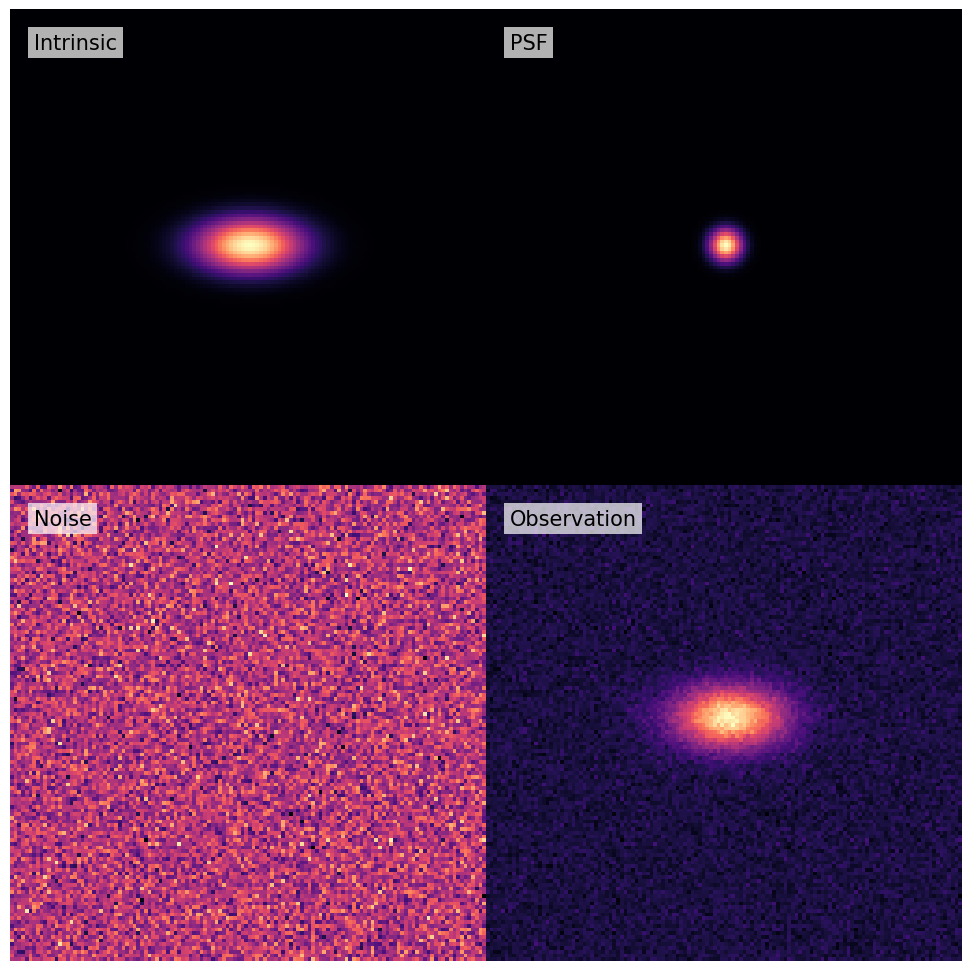

In [64]:
# grid
N= 128
x = np.arange(0, N, 1) - N/2
y = np.arange(0, N, 1) - N/2
X, Y = np.meshgrid(x, y)

star = gaussian_2d(X, Y, 0, 0, 10, 5)
star /= np.sum(star)
star *= 1000
psf = gaussian_2d(X, Y, 0, 0, 3, 3)
psf /= np.sum(psf)
observation = fftconvolve(star, psf, mode='same')
noise = np.random.normal(0, 0.1, (N, N))
observation += noise
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10, 10), gridspec_kw={'wspace': 0, 'hspace': 0})
axes = axes.flatten()
axes[0].pcolormesh(X, Y, star, rasterized=True)
axes[0].text(0.05, 0.95, 'Intrinsic', transform=axes[0].transAxes,
                        ha='left', va='top', fontsize=15,
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
axes[1].pcolormesh(X, Y, psf, rasterized=True)
axes[1].text(0.05, 0.95, 'PSF', transform=axes[1].transAxes,
                        ha='left', va='top', fontsize=15,
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
axes[2].pcolormesh(X, Y, noise, rasterized=True)
axes[2].text(0.05, 0.95, 'Noise', transform=axes[2].transAxes,
                        ha='left', va='top', fontsize=15,
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
axes[3].pcolormesh(X, Y, observation, rasterized=True)
axes[3].text(0.05, 0.95, 'Observation', transform=axes[3].transAxes,
                        ha='left', va='top', fontsize=15,
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.savefig('../../results/figures/simulation/fiducial_model.pdf', bbox_inches="tight", pad_inches=0)
plt.show()

### Deconvolution

C:\Users\Niels de Klerk\AppData\Local\Temp\ipykernel_18288\422292713.py:24: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(weight_sizes, np.sqrt(weight_sizes**2-9), '--', c='gold', lw=3, label=r'$\sqrt{\sigma_\mathrm{weight}^2-\sigma_\mathrm{PSF}^2}$')


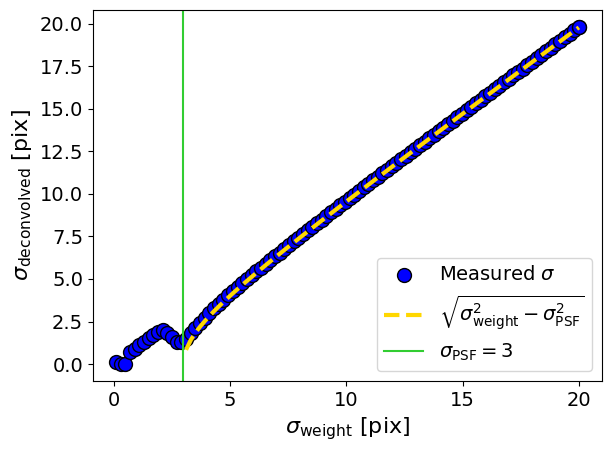

In [65]:
from scipy.optimize import curve_fit
weight_sizes = np.linspace(0.1, 20, 100)
psf = gaussian_2d(X, Y, 0, 0, 3, 3)
psf /= np.sum(psf)
psfdecon = PSFDeconvolver(psf)
psfdecon.prepare(128, eps=1e-16)
gaussian = lambda A, sigma: gaussian_2d(X, Y, 0, 0, sigma, sigma, 0, A)
def model(coords, A, sigma):
    return gaussian(A, sigma).ravel()

for weight_size in weight_sizes:
    FT_weight = fourier_gaussian_2d(
                    psfdecon.KX, psfdecon.KY,
                    weight_size, weight_size
                )
    weight_rescale = fft.irfft2(
        psfdecon.psf_prefactor * FT_weight
    )
    popt, _ = curve_fit(model, None, weight_rescale.ravel(), p0=[.5, weight_size], bounds=[(0, 0), (np.inf, weight_size)])
    plt.scatter(weight_size, popt[1], c='b', s=100, edgecolor='k')
plt.scatter(weight_size, popt[1], c='b', s=100, edgecolor='k', label=r'Measured $\sigma$')
plt.xlabel(r'$\sigma_\mathrm{weight}$ [pix]')
plt.ylabel(r'$\sigma_\mathrm{deconvolved}$ [pix]')
plt.plot(weight_sizes, np.sqrt(weight_sizes**2-9), '--', c='gold', lw=3, label=r'$\sqrt{\sigma_\mathrm{weight}^2-\sigma_\mathrm{PSF}^2}$')
plt.axvline(3, label=r'$\sigma_\mathrm{PSF} = 3$', color='k', c='limegreen')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../../results/figures/simulation/deconvolution_relation.pdf', bbox_inches="tight", pad_inches=0)
plt.show()

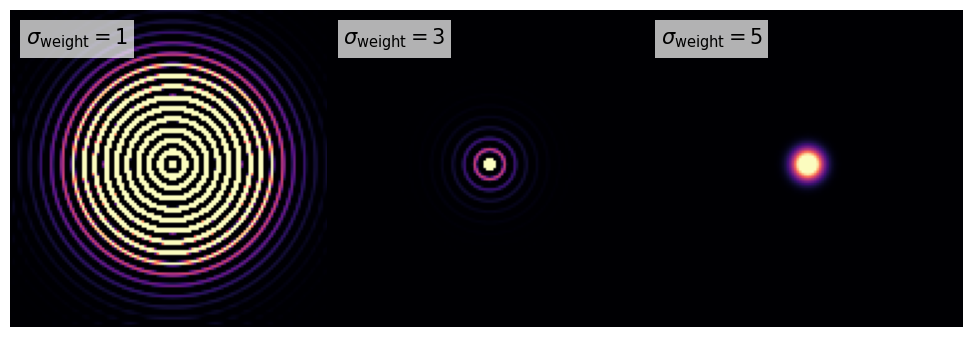

In [66]:
weights = [1, 3, 5]
fig, axes = plt.subplots(1, len(weights), sharex=True, sharey=True, figsize=(10, 10), gridspec_kw={'wspace': 0, 'hspace': 0})
axes = axes.flatten()
psfdecon = PSFDeconvolver(psf)
psfdecon.prepare(128)
for i, weight_size in enumerate(weights):
    # weight = gaussian_2d(X, Y, 0, 0, weight_size, weight_size)
    FT_weight = fourier_gaussian_2d(
                    psfdecon.KX, psfdecon.KY,
                    weight_size, weight_size, 0
                )
    weight_rescale = fft.irfft2(
        psfdecon.psf_prefactor * FT_weight
    )
    axes[i].imshow(weight_rescale, vmin=0, vmax=1)
    axes[i].text(0.05, 0.95, r'$\sigma_\mathrm{weight}=$' +f'{weight_size}', transform=axes[i].transAxes,
                        ha='left', va='top', fontsize=15,
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    axes[i].axis('off')
# axes[0].pcolormesh(X, Y, star, rasterized=True)
# axes[0].text(0.05, 0.95, 'Intrinsic', transform=axes[0].transAxes,
#                         ha='left', va='top', fontsize=15,
#                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
# axes[1].pcolormesh(X, Y, psf, rasterized=True)
# axes[1].text(0.05, 0.95, 'PSF', transform=axes[1].transAxes,
#                         ha='left', va='top', fontsize=15,
#                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
# axes[2].pcolormesh(X, Y, noise, rasterized=True)
# axes[2].text(0.05, 0.95, 'Noise', transform=axes[2].transAxes,
#                         ha='left', va='top', fontsize=15,
#                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
# axes[3].pcolormesh(X, Y, observation, rasterized=True)
# axes[3].text(0.05, 0.95, 'Observation', transform=axes[3].transAxes,
#                         ha='left', va='top', fontsize=15,
#                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
# for ax in axes:
#     ax.axis('off')
plt.tight_layout()
plt.savefig('../../results/figures/simulation/2_regimes.pdf',bbox_inches="tight", pad_inches=0)
plt.show()

### Measured Flux in different parts of the image

In [73]:
# grid
N= 128
x = np.arange(0, N, 1) - N/2
y = np.arange(0, N, 1) - N/2
X, Y = np.meshgrid(x, y)

star = gaussian_2d(X, Y, 0, 0, 10, 5)
star /= np.sum(star)
star *= 1000
psf = gaussian_2d(X, Y, 0, 0, 3, 3)
psf /= np.sum(psf)
observation = fftconvolve(star, psf, mode='same')
noise = np.random.normal(0, 0.01, (N, N))
observation += noise*1
weight_size = 6
weight = gaussian_2d(X, Y, 0, 0, weight_size, weight_size)
center_array = np.linspace(-63, 63, 100)
centers = np.empty((len(center_array),len(center_array), 2))
true_F = np.empty((len(center_array),len(center_array)))
for a, i in enumerate(center_array):
    for b, j in enumerate(center_array):
        weight = gaussian_2d(X, Y, i, j, weight_size, weight_size)
        centers[a,b] = (i+N/2, j+N/2)
        true_F[a, b] = np.sum(weight*star)
centers = centers.reshape(-1, 2)
true_F = true_F.flatten()
psfdecon = PSFDeconvolver(psf)
psfdecon.prepare(128)
measured_flux = flux(observation, centers, psfdecon, weight_sizes=weight_size, cutout_size=128)
measured_accuracy = (measured_flux - true_F) /true_F

Measuring Flux: 100%|██████████| 10000/10000 [00:00<00:00, 12529.23it/s]


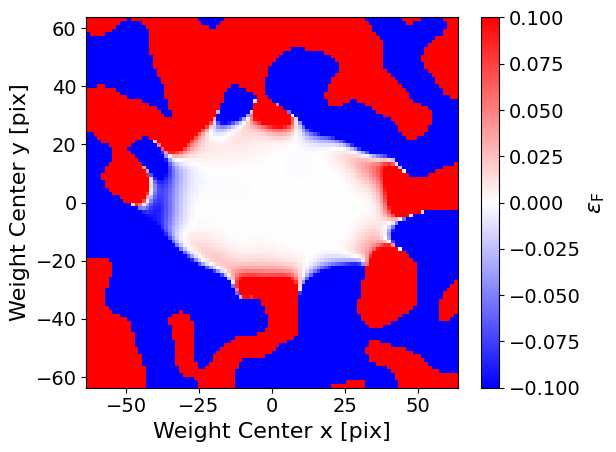

In [74]:
X, Y = np.meshgrid(center_array, center_array)
plt.pcolormesh(X, Y, measured_accuracy.reshape(len(center_array), len(center_array)).T, vmin=-.1, vmax=.1, cmap='bwr', rasterized=True)
plt.colorbar(label=r'$\epsilon_\mathrm{F}$')
# plt.contour(
#     X, Y, np.abs(fft.fftshift(measured_accuracy.reshape(len(center_array), len(center_array)))),
#     levels=[0.01],
#     colors='gold',
#     linewidths=3
# )
plt.xlabel('Weight Center x [pix]')
plt.ylabel('Weight Center y [pix]')
plt.tight_layout()
plt.savefig('../../results/figures/simulation/center_accuracy.pdf', bbox_inches="tight", pad_inches=0)
plt.show()

### Measured Flux for different weights and PSFs

In [75]:
N= 128
x = np.arange(0, N, 1) - N/2
y = np.arange(0, N, 1) - N/2
X, Y = np.meshgrid(x, y)
star = gaussian_2d(X, Y, 0, 0, 10, 5)
star /= np.sum(star)
star *= 1000
noise = np.random.normal(0, 0.1, (N, N))
N_points = 200
weight_sizes = np.linspace(0.1, 20, N_points)
psf_sizes = np.linspace(0.1, 20, N_points)
flux_err = np.zeros((N_points, N_points))

true_F = np.empty_like(weight_sizes)
for i, weight_size in enumerate(weight_sizes):
    weight = gaussian_2d(X, Y, 0, 0, weight_size, weight_size)
    true_F[i] = np.sum(weight*star)

for j, psf_size in enumerate(psf_sizes):
    psf = gaussian_2d(X, Y, 0, 0, psf_size, psf_size)
    psf /= np.sum(psf)
    observation = fftconvolve(star, psf, mode='same')
    observation += noise
    psfdecon = PSFDeconvolver(psf)
    psfdecon.prepare(128)
    measured_flux = flux(observation, (N/2, N/2), psfdecon, weight_sizes=weight_sizes, cutout_size=128, show_progress=False)
    flux_err[:,j] = (measured_flux - true_F) / true_F

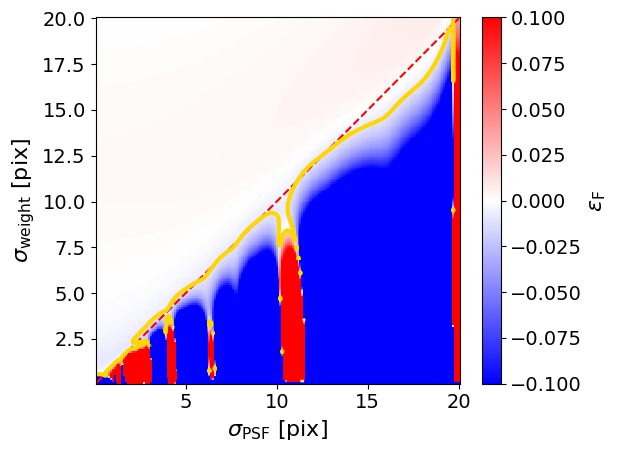

In [76]:
X, Y = np.meshgrid(psf_sizes, weight_sizes)
plt.pcolormesh(X, Y, flux_err, cmap='bwr', vmin=-.1, vmax=.1, rasterized=True)
plt.plot([psf_sizes[0], psf_sizes[-1]], [psf_sizes[0], psf_sizes[-1]], 'r--')
plt.colorbar(label=r'$\epsilon_\mathrm{F}$')
plt.contour(
    X, Y, np.abs(flux_err),
    levels=[0.01],
    colors='gold',
    linewidths=3
)
plt.xlabel(r'$\sigma_\mathrm{PSF}$ [pix]')
plt.ylabel(r'$\sigma_\mathrm{weight}$ [pix]')
plt.tight_layout()
plt.savefig('../../results/figures/simulation/flux_accuracy.pdf', bbox_inches="tight", pad_inches=0)
plt.show()

### PSF sized used in measurement compared to true size

In [77]:
X, Y = np.meshgrid(x, y)
star = gaussian_2d(X, Y, 0, 0, 10, 5)
star /= np.sum(star)
star *= 1000
actual_psf_size = 3
psf = gaussian_2d(X, Y, 0, 0, actual_psf_size, actual_psf_size, 1)
psf /= np.sum(psf)
observation = fftconvolve(star, psf, mode='same') + noise
weight_size = 20
weight = gaussian_2d(X, Y, 0, 0, weight_size, weight_size)
psf_sizes = np.linspace(.1, 20, 200)
flux_err = np.zeros((len(psf_sizes), len(psf_sizes)))
for i, true_psf_size in enumerate(psf_sizes):
    psf = gaussian_2d(X, Y, 0, 0, true_psf_size, true_psf_size, 1)
    psf /= np.sum(psf)
    observation = fftconvolve(star, psf, mode='same') + noise
    for j, psf_size in enumerate(psf_sizes):
        psf_new = gaussian_2d(X, Y, 0, 0, psf_size, psf_size)
        psf_new /= np.sum(psf_new)
        psfdecon = PSFDeconvolver(psf_new)
        psfdecon.prepare(128)
        true_F = np.sum(weight*star)
        measured_flux = flux(observation, (N/2, N/2), psfdecon, weight_sizes=weight_size, cutout_size=128, show_progress=False)[0]
        flux_err[i, j] =  (measured_flux - true_F) / true_F

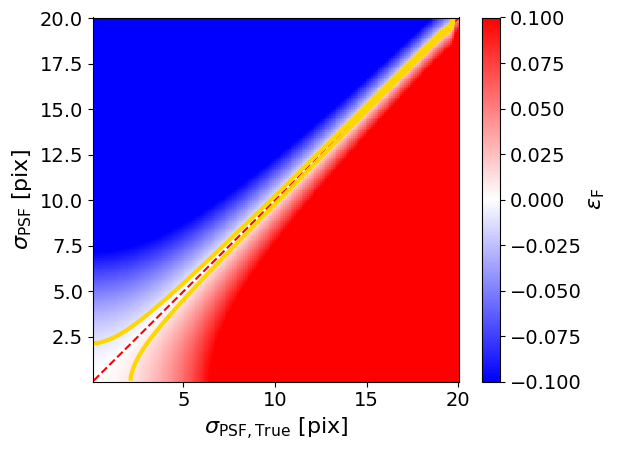

In [79]:
X, Y = np.meshgrid(psf_sizes, psf_sizes)
plt.pcolormesh(X, Y, flux_err, cmap='bwr', vmin=-0.1, vmax=.1, rasterized=True)
plt.plot([psf_sizes[0], psf_sizes[-1]], [psf_sizes[0], psf_sizes[-1]], 'r--')
plt.colorbar(label=r'$\epsilon_\mathrm{F}$')
plt.contour(
    X, Y, np.abs(flux_err),
    levels=[0.01],
    colors='gold',
    linewidths=3
)
plt.xlabel(r'$\sigma_\mathrm{PSF,True}$ [pix]')
plt.ylabel(r'$\sigma_\mathrm{PSF}$ [pix]')
plt.tight_layout()
plt.savefig('../../results/figures/simulation/psf_dependence.pdf', bbox_inches="tight", pad_inches=0)
plt.show()

### Real Noise compared to Measured Noise

In [236]:
from psf_module import compute_psf_column

In [254]:
N_trials = 1000
N= 128
noise_images = np.random.normal(0, .1, (N_trials, N, N))
noise_models = []

x = np.arange(0, N, 1) - N/2
y = np.arange(0, N, 1) - N/2
X, Y = np.meshgrid(x, y)
star = gaussian_2d(X, Y, 0, 0, 10, 5, 100)
star /= np.sum(star)
star *= 1000
N_points = 100

weight_sizes = np.linspace(0.1, 20, N_points)
psf_sizes = np.linspace(0.1, 20, N_points)
sigma_err = np.zeros((N_points, N_points))

results = []

results = Parallel(n_jobs=-1, backend="loky")(
    delayed(compute_psf_column)(
        j,
        psf_sizes[j],
        weight_sizes,
        X,
        Y,
        star,
        noise_images,
        N_trials,
        N
    )
    for j in tqdm(range(N_points))
)

for j, col in results:
    sigma_err[:, j] = col
# np.save('sigma_err.npy', sigma_err)


100%|██████████| 100/100 [51:21<00:00, 30.81s/it][A


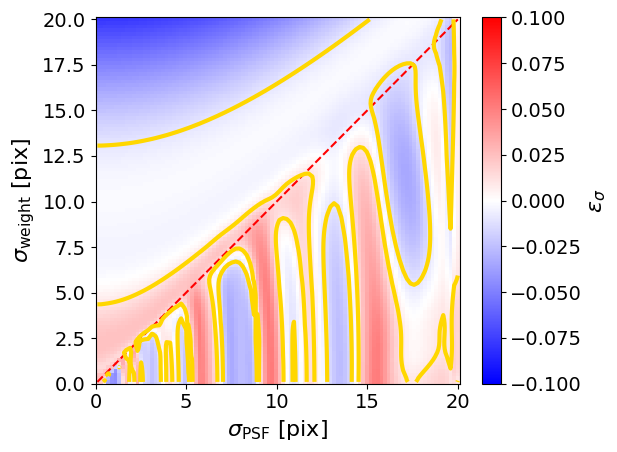

In [266]:
sigma_err = np.load('sigma_err.npy')
N_points = 100

weight_sizes = np.linspace(0.1, 20, N_points)
psf_sizes = np.linspace(0.1, 20, N_points)
X, Y = np.meshgrid(psf_sizes, weight_sizes)
plt.pcolormesh(X, Y, sigma_err, vmin=-.1, vmax=.1,cmap='bwr', rasterized=True)
plt.plot([psf_sizes[0], psf_sizes[-1]], [psf_sizes[0], psf_sizes[-1]], 'r--')
plt.colorbar(label=r'$\epsilon_{\sigma}$')
plt.contour(
    X, Y, np.abs(sigma_err),
    levels=[0.01],
    colors='gold',
    linewidths=3
)
plt.xlabel(r'$\sigma_\mathrm{PSF}$ [pix]')
plt.ylabel(r'$\sigma_\mathrm{weight}$ [pix]')
plt.tight_layout()
plt.savefig('../../results/figures/simulation/sigma_accuracy.pdf', bbox_inches="tight", pad_inches=0)
plt.show()

### Measured Flux for different weight dimensions

In [80]:
N= 128
x = np.arange(0, N, 1) - N/2
y = np.arange(0, N, 1) - N/2
X, Y = np.meshgrid(x, y)
star = gaussian_2d(X, Y, 0, 0, 10, 5)
star /= np.sum(star)
star *= 1000
psf = gaussian_2d(X, Y, 0, 0, 3, 3)
psf /= np.sum(psf)
observation = fftconvolve(star, psf, mode='same')
noise = np.random.normal(0, 0.1, (N, N))
observation += noise
N_points = 100
weight_sizes = np.linspace(0.1, 20, N_points)
flux_err = np.zeros((N_points, N_points))

true_F = np.empty((N_points, N_points))
weights = np.empty((N_points, N_points, 2))
for i, weight_size_a in enumerate(weight_sizes):
    for j, weight_size_b in enumerate(weight_sizes):
        weight = gaussian_2d(X, Y, 0, 0, weight_size_a, weight_size_b)
        true_F[i, j] = np.sum(weight*star)
        weights[i, j] = (weight_size_a, weight_size_b)
weights = weights.reshape(-1, 2)
true_F = true_F.flatten()
psfdecon = PSFDeconvolver(psf)
psfdecon.prepare(128)
observation = fftconvolve(star, psf, mode='same') + noise
measured_flux = flux(observation, (N/2, N/2), psfdecon, weight_sizes=np.hstack([weights, np.zeros((N_points*N_points, 1))]), cutout_size=128, show_progress=False)
measured_accuracy = (measured_flux - true_F) / true_F


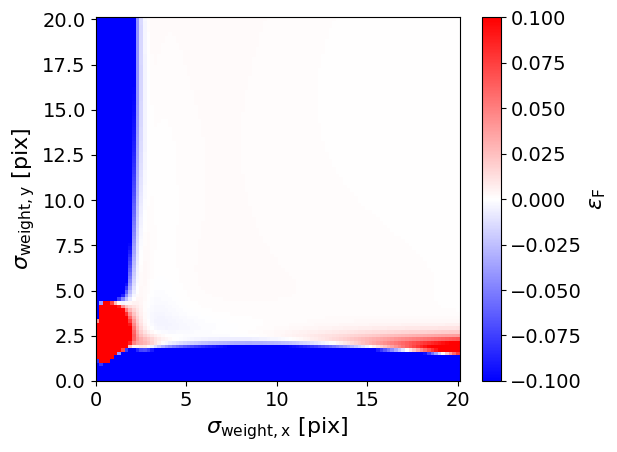

In [81]:
X, Y = np.meshgrid(weight_sizes, weight_sizes)
plt.pcolormesh(X, Y, measured_accuracy.reshape(N_points, N_points), cmap='bwr',  vmin=-0.1, vmax=.1, rasterized=True)
plt.colorbar(label=r'$\epsilon_\mathrm{F}$')
plt.xlabel(r'$\sigma_\mathrm{weight,x}$ [pix]')
plt.ylabel(r'$\sigma_\mathrm{weight,y}$ [pix]')
plt.tight_layout()
plt.savefig('../../results/figures/simulation/weight_accuracy.pdf', bbox_inches="tight", pad_inches=0)
plt.show()

### Measured SNR for different weight dimensions

In [88]:
N= 128
x = np.arange(0, N, 1) - N/2
y = np.arange(0, N, 1) - N/2
X, Y = np.meshgrid(x, y)
star = gaussian_2d(X, Y, 0, 0, 10, 5)
star /= np.sum(star)
star *= 1000
psf = gaussian_2d(X, Y, 0, 0, 3, 3)
psf /= np.sum(psf)
observation = fftconvolve(star, psf, mode='same')
noise = np.random.normal(0, .1, (N, N))
observation += noise
N_points = 100
weight_sizes = np.linspace(0.1, 20, N_points)
flux_err = np.zeros((N_points, N_points))

true_F = np.empty((N_points, N_points))
weights = np.empty((N_points, N_points, 2))
for i, weight_size_a in enumerate(weight_sizes):
    for j, weight_size_b in enumerate(weight_sizes):
        weight = gaussian_2d(X, Y, 0, 0, weight_size_a, weight_size_b)
        true_F[i, j] = np.sum(weight*star)
        weights[i, j] = (weight_size_a, weight_size_b)
noise_model = NoiseModel(noise)
noise_model.set_noise_square(noise)
noise_model.set_noise_covariance(N//2)

weights = weights.reshape(-1, 2)
true_F = true_F.flatten()
psfdecon = PSFDeconvolver(psf)
psfdecon.prepare(128)
observation = fftconvolve(star, psf, mode='same') + noise
measured_flux, variance = flux(observation, (N/2, N/2), psfdecon, weight_sizes=np.hstack([weights, np.zeros((N_points*N_points, 1))]), noise_model=noise_model, cutout_size=128)
measured_snr = measured_flux / np.sqrt(variance)

Measuring Flux: 100%|██████████| 10000/10000 [00:08<00:00, 1207.43it/s]


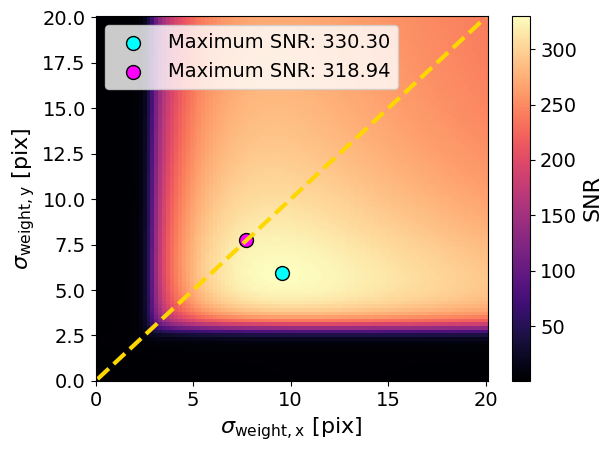

In [89]:
X, Y = np.meshgrid(weight_sizes, weight_sizes)
grid_snr = measured_snr.reshape(N_points, N_points).T
plt.pcolormesh(X, Y, grid_snr, rasterized=True)
plt.colorbar(label=r'SNR')
# index of maximum in 2D grid
imax = np.argmax(grid_snr)
iy, ix = np.unravel_index(imax, grid_snr.shape)

# coordinates of maximum
xmax = X[iy, ix]
ymax = Y[iy, ix]
plt.plot([weight_sizes[0], weight_sizes[-1]], [weight_sizes[0], weight_sizes[-1]], linestyle='--', color='gold', lw=3)
plt.scatter(xmax, ymax, c='cyan', s=100, edgecolors='black', label=f'Maximum SNR: {np.max(grid_snr):.2f}')

# diagonal values (where sigma_x = sigma_y)
diag_vals = np.diag(grid_snr)

# max along diagonal
i = np.argmax(diag_vals)

xmax = weight_sizes[i]
ymax = weight_sizes[i]

plt.scatter(xmax, ymax, c='magenta', s=100, edgecolors='black', label=f'Maximum SNR: {np.max(diag_vals):.2f}')


plt.xlabel(r'$\sigma_\mathrm{weight,x}$ [pix]')
plt.ylabel(r'$\sigma_\mathrm{weight,y}$ [pix]')
plt.legend()
plt.tight_layout()
plt.savefig('../../results/figures/simulation/weight_size_snr.pdf', bbox_inches="tight", pad_inches=0)
plt.show()

### Testing RMS implementation

In [258]:
from psf_module import compute_psf_column_rms

In [259]:
N_trials = 1000
N= 128
noise_images = np.random.normal(0, .1, (N_trials, N, N))
noise_models = []

x = np.arange(0, N, 1) - N/2
y = np.arange(0, N, 1) - N/2
X, Y = np.meshgrid(x, y)
star = gaussian_2d(X, Y, 0, 0, 10, 5, 100)
star /= np.sum(star)
star *= 1000
N_points = 100

weight_sizes = np.linspace(0.1, 20, N_points)
psf_sizes = np.linspace(0.1, 20, N_points)
sigma_err = np.zeros((N_points, N_points))

results = []

results = Parallel(n_jobs=-1, backend="loky")(
    delayed(compute_psf_column_rms)(
        j,
        psf_sizes[j],
        weight_sizes,
        X,
        Y,
        star,
        noise_images,
        N_trials,
        N
    )
    for j in tqdm(range(N_points))
)

for j, col in results:
    sigma_err[:, j] = col
np.save('sigma_rms_err.npy', sigma_err)


100%|██████████| 100/100 [51:18<00:00, 30.78s/it][A


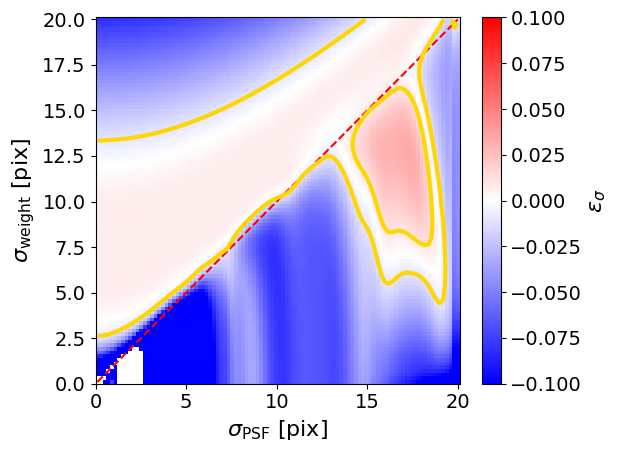

In [265]:
sigma_err = np.load('sigma_rms_err.npy')
X, Y = np.meshgrid(psf_sizes, weight_sizes)
plt.pcolormesh(X, Y, sigma_err, vmin=-.1, vmax=.1,cmap='bwr', rasterized=True)
plt.plot([psf_sizes[0], psf_sizes[-1]], [psf_sizes[0], psf_sizes[-1]], 'r--')
plt.colorbar(label=r'$\epsilon_{\sigma}$')
plt.contour(
    X, Y, np.abs(sigma_err),
    levels=[0.01],
    colors='gold',
    linewidths=3
)
plt.xlabel(r'$\sigma_\mathrm{PSF}$ [pix]')
plt.ylabel(r'$\sigma_\mathrm{weight}$ [pix]')
plt.tight_layout()
plt.savefig('../../results/figures/simulation/rms_accuracy.pdf', bbox_inches="tight", pad_inches=0)
plt.show()